# Deep Finance Researcher with TODO planner
Build an itelligent agent with task planning that can search financial documents (RAG) and live market data 

### Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
import sys
sys.path.append("D:/Cursos/Agentes/financial_deep_research_agent")

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
#Langchain built-in middkewares
from langchain.agents.middleware import TodoListMiddleware, SummarizationMiddleware

from agent.rag_tools import live_finance_researcher, hybrid_search
from agent.prompts import MULTIMODEL_AGENT_PROMPT
from agent.agent_utils import stream_agent_response

In [8]:
model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview') 

### Create Agent with TODO planner and Sumarization

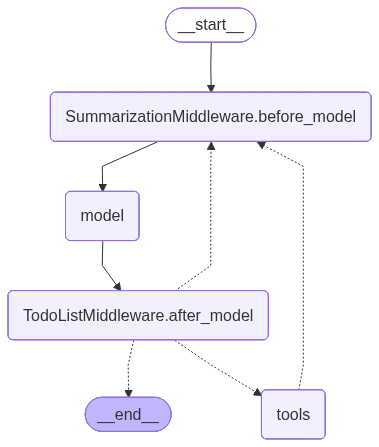

In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3


def get_agent():
    conn = sqlite3.connect('D:/Cursos/Agentes/financial_deep_research_agent/data/sqlite/financial_research_agent.db', check_same_thread=False)
    checkpointer = SqliteSaver(conn=conn)
    agent = create_agent(
        model=model,
        tools=[live_finance_researcher, hybrid_search],
        system_prompt=MULTIMODEL_AGENT_PROMPT,
        checkpointer=checkpointer,
        middleware=[
            SummarizationMiddleware(
                model=model,
                trigger=[('messages', 25)],
                keep=('messages', 10)
            ),
            TodoListMiddleware()
        ]
    )
    return agent

agent = get_agent()
agent

### Examples

In [12]:
stream_agent_response(agent, "what was amazon's revenue in q1 2024", thread_id="session10")

## SESSION INTENT
The user's primary goal is to retrieve, analyze, and compare financial data (revenue, cash flows) and current market performance for major technology companies, specifically Apple (AAPL), Alphabet/Google (GOOGL), Microsoft (MSFT), and Amazon (AMZN), using a combination of live research tools and internal SEC filing documents.

## SUMMARY
- **Apple (AAPL):** Current stock price is $300.23. Key news includes an Indian antitrust case, iPhone 17 discounts in China, and reports on profit margins from "imperfect chips."
- **Alphabet (Google):** Revenue for Q1 2024 was $80,539 million compared to $69,787 million in Q1 2023, representing a 15.4% year-over-year increase. This was derived from the Q2 2024 10-Q filing.
- **Amazon (AMZN):** 2024 cash flow data shows $115,877 million from operating activities and a net cash increase of $8,422 million, sourced from the 2024 10-K filing.
- **Microsoft (MSFT):** Current stock price is $421.92 with a "Strong Buy" analyst rating. Attem

In [13]:
stream_agent_response(agent, "what is the current stock price of tesla and latest news", thread_id="session10")


 Tool called: write_todos

 Args: {'todos': [{'status': 'in_progress', 'content': 'Search historical SEC filings for Tesla context.'}, {'status': 'pending', 'content': 'Get current Tesla stock price and news via live researcher.'}, {'content': 'Synthesize information and provide the final answer.', 'status': 'pending'}]}



 Tool called: hybrid_search

 Args: {'query': 'Tesla latest financial reports and company updates 2024 2025'}



 Tool result (length: 298)

{"company_name": "tesla", "doc_type": null, "fiscal_year": "2025", "fical_quarter": null}
 Tool result (length: 0)


 Tool called: write_todos

 Args: {'todos': [{'status': 'completed', 'content': 'Search historical SEC filings for Tesla context.'}, {'content': 'Get current Tesla stock price and news via live researcher.', 'status': 'in_progress'}, {'status': 'pending', 'content': 'Synthesize information and provide the final answer.'}]}



 Tool called: live_finance_researcher

 Args: {'query': 'current stock price and latest

Exception in thread Thread-79 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 1305: character maps to <undefined>



 Tool result (length: 22)


 Tool called: live_finance_researcher

 Args: {'query': 'Tesla TSLA stock price news today'}



 Tool result (length: 1560)


 Tool called: write_todos

 Args: {'todos': [{'status': 'completed', 'content': 'Search historical SEC filings for Tesla context.'}, {'status': 'completed', 'content': 'Get current Tesla stock price and news via live researcher.'}, {'status': 'in_progress', 'content': 'Synthesize information and provide the final answer.'}]}



 Tool result (length: 302)

Tesla's stock (TSLA) is currently trading at **$404.11** in regular market hours, with pre-market activity showing an increase to **$408.29** (+1.03%).

### Current Stock Performance
*   **Last Close:** $409.99
*   **Today's Range:** $393.63 – $405.63
*   **Change:** -$5.88 (-1.43%) in the most recent regular session.

### Latest News and Market Sentiment
*   **Model S Strategy:** Recent reports suggest Tesla is shifting focus away from the Model S and Model X as Mercedes-Benz attem

In [14]:
stream_agent_response(agent, "Compare microsoft's Q2 2024 revenue form SEC filings with its current stock performance", thread_id="session11")


 Tool called: write_todos

 Args: {'todos': [{'content': "Search for Microsoft's Q2 2024 SEC filings revenue data.", 'status': 'in_progress'}, {'status': 'pending', 'content': 'Get current Microsoft stock price and performance data.'}, {'content': 'Synthesize and compare Q2 2024 performance with current stock trends.', 'status': 'pending'}]}



 Tool result (length: 319)


 Tool called: hybrid_search

 Args: {'query': 'Microsoft revenue Q2 2024 December 31 2023 10-Q filing'}


{"company_name": "microsoft", "doc_type": "10-q", "fiscal_year": "2024", "fical_quarter": "q2"}
 Tool result (length: 0)


 Tool called: hybrid_search

 Args: {'query': 'Microsoft 10-Q revenue fiscal year 2024 Q2 Q3 Q4'}


{"company_name": "microsoft", "doc_type": "10-q", "fiscal_year": "2024", "fical_quarter": null}
 Tool result (length: 0)


 Tool called: hybrid_search

 Args: {'query': 'Microsoft revenue 2024 10-Q'}


{"company_name": "microsoft", "doc_type": "10-q", "fiscal_year": "2024", "fical_quarter": nu